# 210 — MHC benchmark: data, ground truth, and the one-to-many label policy

Everything in the MHC block (211–215) scores the same 25 human MHC genes against the same mouse
proteome, and every one of those scores depends on one decision: *what counts as a true ortholog
when a gene has more than one?* This notebook makes that decision explicit, applies it once, and
writes a single labelled pair table the rest of the block reads. Nothing downstream re-derives
ground truth.

It replaces section 0 of the old notebook 201, which has been split into one concept per notebook:

| notebook | question |
|---|---|
| **210 (this one)** | what are the data, the labels, and the label *policy*? |
| [211](./211_mhc_recovery_and_auc.ipynb) | which alphabet × k-size detects MHC orthologs at all? |
| [212](./212_mhc_domain_localisation.ipynb) | *where* on the protein do the shared k-mers land? |
| [213](./213_mhc_metric_choice.ipynb) | which similarity metric ranks candidates best? |
| [214](./214_mhc_igsf_specificity.ipynb) | is this MHC-specific, or generic immunoglobulin-superfamily? |
| [215](./215_mhc_synteny_ground_truth.ipynb) | does genomic position agree, as an independent ground truth? |

## Why the label policy matters

MHC class I is a birth-and-death family (Nei, Gu & Sitnikova 1997, *PNAS* 94:7799–7806,
doi:10.1073/pnas.94.15.7799): HLA-B, HLA-C and HLA-F each have **15** MGI-listed mouse partners, and
11 of the 25 query genes have more than one. So "is this pair a true ortholog?" has no answer until
a rule is named, and the three defensible rules give materially different numbers:

- **`any_member`** — every MGI-listed partner is a positive. Standard and assumption-light, but the
  positive set grows with the expansion, so a 14-positive class I gene and a 1-positive class II
  gene are scored on different problems. Class I and class II AUCs are **not comparable** under this
  rule, which is what the old notebook was doing implicitly.
- **`best_scoring_member`** — only the highest-scoring MGI partner is a positive. Gives a size-1
  positive set, but chooses the label using the score being evaluated. **Circular**, and it inflates
  AUC by construction. Reported as an upper bound, never as a headline.
- **`synteny_nearest`** — only the partner sitting closest to the position local synteny predicts is
  a positive. Also size-1, but decided by **genomic position**, which does not come from the protein
  sequence, so it is not circular. This is the headline policy, and the only rule under which a
  one-to-many class I number means the same thing as a 1:1 class II number.

All three are computed and carried side by side in the output table. Any downstream claim has to
name which one it used.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import ortholog_analysis_utils as ou

RES = Path("/Users/olga/data/gencode/results-human-mouse-orthologs")
FIG_DIR = Path("../figures")  # repo-level figures/, tracked in git

# Every alphabet x ksize combo notebook 200 has real genome-wide results for. Single source of
# truth (ou.load_all_alphabet_ksize_combos, reads 200's two sweep CSVs) so this block can't drift
# from what 200 actually scored -- add a new alphabet/ksize there first and it shows up here.
combos_df = ou.load_all_alphabet_ksize_combos()
# Drop the legacy "hp" encoding: kmerseek's --help states hp IS the Lehninger classification, and
# they are byte-identical here (hp_k26 and hp_lehninger_k26 both give exactly 3_266 MHC rows). It
# survives in 200's sweep only because those combos predate the explicitly-named HP variants, and
# its files are the older human_vs_mouse.hp.k*.results.csv.gz set -- partly absent (k23, k25) and
# partly corrupt (k21 fails `gzip -t`). hp-lehninger covers the same k range from current parquets.
combos_df = combos_df.filter(pl.col("dash_encoding") != "hp")
COMBOS = list(zip(combos_df["dash_encoding"].to_list(), combos_df["ksize"].to_list()))
ALPHABET_DISPLAY_NAMES = dict(
    zip(combos_df["dash_encoding"].to_list(), combos_df["display_encoding"].to_list())
)


def combo_label(enc: str, k: int) -> str:
    return f"{ALPHABET_DISPLAY_NAMES.get(enc, enc)}_k{k}"


# MHC taxonomy, domain architecture and per-alphabet colors all live in ortholog_analysis_utils
# now (ou.MHC_CLASSES / ou.MHC_CLASS_ORDER / ou.DOMAINS_CLASS_I / ...), shared by 210-215 so a
# correction lands everywhere at once instead of drifting between notebooks.
MHC_CLASSES, CLASS_ORDER = ou.MHC_CLASSES, ou.MHC_CLASS_ORDER
ALPHABET_CMAPS, COMBO_COLORS = ou.alphabet_combo_colors(COMBOS, ALPHABET_DISPLAY_NAMES)

print(
    f"{len(COMBOS)} combos across {combos_df['display_encoding'].n_unique()} alphabets"
)
print(
    combos_df.group_by("display_encoding")
    .agg(
        pl.col("ksize").min().alias("k_min"),
        pl.col("ksize").max().alias("k_max"),
        pl.len().alias("n_k"),
    )
    .sort("display_encoding")
)
print(
    f"\n{len(MHC_CLASSES)} human MHC query genes across {len(set(MHC_CLASSES.values()))} classes"
)

77 combos across 8 alphabets
shape: (8, 4)
┌─────────────────────┬───────┬───────┬─────┐
│ display_encoding    ┆ k_min ┆ k_max ┆ n_k │
│ ---                 ┆ ---   ┆ ---   ┆ --- │
│ str                 ┆ i64   ┆ i64   ┆ u32 │
╞═════════════════════╪═══════╪═══════╪═════╡
│ dayhoff             ┆ 10    ┆ 20    ┆ 11  │
│ hp_kyte_doolittle   ┆ 18    ┆ 30    ┆ 4   │
│ hp_lehninger        ┆ 18    ┆ 30    ┆ 13  │
│ hp_lehninger_plus_c ┆ 18    ┆ 30    ┆ 13  │
│ hp_pbotc_1st_ed     ┆ 19    ┆ 30    ┆ 12  │
│ hp_thomas_dill      ┆ 23    ┆ 30    ┆ 8   │
│ hp_thomas_dill_no_c ┆ 26    ┆ 30    ┆ 5   │
│ protein             ┆ 5     ┆ 15    ┆ 11  │
└─────────────────────┴───────┴───────┴─────┘

25 human MHC query genes across 7 classes


## 1. Matched regions, per combo

The 25-gene MHC query is **not** re-searched here; searching belongs in the Nextflow pipeline. Each
combo's matched regions are filtered out of that combo's genome-wide pipeline result, so each human
gene competed against all ~21k mouse proteins rather than a curated shortlist. Verified equivalent
before the switch: filtering the genome-wide parquet to the 25 MHC genes reproduces the old
per-combo search CSVs exactly (hp_lehninger k26 3_266 rows, protein k13 226, dayhoff k18 547 —
identical row counts, genes, and containment ranges).

A combo with no genome-wide result is **reported and skipped**, never searched around: that is a gap
for the pipeline to fill. Three failure modes are tracked separately, because only one of them is a
biological statement:

- **missing** — no pipeline output for this combo at all.
- **unreadable** — output exists but is corrupt (e.g. a truncated `.csv.gz` failing `gzip -t`).
- **zero rows** — output exists and is readable but returned nothing for all 25 genes. Every
  observed case has been an *incomplete* pipeline run (hp-kyte-doolittle k22 has 55M rows but covers
  only 997 of ~19_664 human genes, so MHC was never searched), not an absence of homology. These are
  excluded and reported, never plotted as a negative result.

In [2]:
frames, missing, unreadable, no_hits = [], [], [], []
for enc, k in COMBOS:
    label = combo_label(enc, k)
    cache_csv = RES / f"210_human_mhc_vs_mouse.{label}.csv"

    if cache_csv.exists():
        combo_df = pl.read_csv(cache_csv)
    else:
        try:
            combo_df = (
                ou.scan_genome_wide_results(enc, k)
                .with_columns(
                    pl.col("query_name")
                    .str.split("|")
                    .list.get(6)
                    .str.to_uppercase()
                    .alias("_hg")
                )
                .filter(pl.col("_hg").is_in(list(MHC_CLASSES)))
                .drop("_hg")
                .collect(engine="streaming")
            )
        except FileNotFoundError:
            missing.append(label)
            print(
                f"{label:24s}: NO genome-wide result -- run it in the pipeline, skipping"
            )
            continue
        except Exception as exc:
            unreadable.append(label)
            print(
                f"{label:24s}: UNREADABLE source ({type(exc).__name__}) -- re-run it, skipping"
            )
            continue
        if combo_df.height:
            combo_df.write_csv(cache_csv)

    # hp_lehninger_k24's cached CSV ships `prob_overlap` instead of `poisson_pvalue` (an older
    # kmerseek schema than every other file here). Left alone, pl.concat(how="diagonal_relaxed")
    # leaves poisson_pvalue all-null for exactly this combo's rows, silently collapsing every
    # p-value-based score in 213 to a constant. Recomputed from n_intersecting_hashes /
    # expected_shared_kmers -- the same Poisson survival-function math the pipeline itself uses,
    # so this recovers the real value rather than substituting a placeholder.
    combo_df = ou.ensure_poisson_pvalue(combo_df)
    combo_df = combo_df.with_columns(
        [
            pl.col("query_name")
            .str.split("|")
            .list.get(6)
            .str.to_uppercase()
            .alias("human_gene"),
            pl.col("target_name")
            .str.split("|")
            .list.get(6)
            .str.to_uppercase()
            .alias("mouse_gene"),
            pl.lit(label).alias("combo"),
            pl.lit(enc).alias("encoding"),
            pl.lit(k).alias("ksize"),
        ]
    )
    if combo_df.height == 0:
        # A 0-row frame read back from a header-only cache CSV types every column String, and
        # diagonal_relaxed concat would then widen Float64 -> String across ALL combos, delivering
        # containment to roc_auc_score as text. Excluded and reported instead.
        no_hits.append(label)
        print(
            f"{label:24s}: 0 rows -- 0/25 MHC genes; check the pipeline run for this combo"
        )
        continue
    frames.append(combo_df)

KEEP = [
    "combo",
    "encoding",
    "ksize",
    "human_gene",
    "mouse_gene",
    "query_name",
    "target_name",
    "containment",
    "jaccard",
    "n_intersecting_hashes",
    "expected_shared_kmers",
    "poisson_pvalue",
    "enrichment",
    "query_tfidf",
    "mean_matched_kmer_freq",
    "query_start",
    "query_end",
    "target_start",
    "target_end",
    "region_length",
]
regions = pl.concat(frames, how="diagonal_relaxed")
regions = regions.select([c for c in KEEP if c in regions.columns])

print(
    f"\n{len(regions):,} matched-region rows across {len(frames)}/{len(COMBOS)} combos"
)
if missing:
    print(f"Missing from the pipeline ({len(missing)}): {', '.join(missing)}")
if unreadable:
    print(f"Unreadable/corrupt sources ({len(unreadable)}): {', '.join(unreadable)}")
if no_hits:
    print(
        f"Zero-row combos, likely incomplete runs ({len(no_hits)}): {', '.join(no_hits)}"
    )

# Guard: the String-widening failure above is silent and downstream-fatal, so assert it didn't happen.
assert (
    regions.select(pl.col("containment").cast(pl.Float64, strict=True)).height
    == regions.height
)

NO_DATA_LABELS = set(missing) | set(unreadable) | set(no_hits)
regions.write_parquet(RES / "210_mhc_matched_regions.parquet")
print(
    f"\nWrote {RES / '210_mhc_matched_regions.parquet'} "
    f"({(RES / '210_mhc_matched_regions.parquet').stat().st_size / 1e6:.0f} MB) -- "
    f"read by 212 and 214 instead of re-scanning 1.6 GB of per-combo CSVs."
)

hp_kyte_doolittle_k18   : 0 rows -- 0/25 MHC genes; check the pipeline run for this combo

2,961,610 matched-region rows across 76/77 combos
Zero-row combos, likely incomplete runs (1): hp_kyte_doolittle_k18

Wrote /Users/olga/data/gencode/results-human-mouse-orthologs/210_mhc_matched_regions.parquet (41 MB) -- read by 212 and 214 instead of re-scanning 1.6 GB of per-combo CSVs.


## 2. MGI ground truth and the candidate pair table

MGI's `HOM_MouseHumanSequence.rpt` homology classes give the human→mouse ortholog partners. Standing
caveat, inherited by everything downstream: **MGI's orthology calls are themselves partly informed
by sequence similarity**, so scoring a sequence-similarity method against them is partly circular.
That motivates the independent synteny ground truth in 215, and the `synteny_nearest` policy below.

Candidates are collapsed to one row per (combo, human gene, mouse gene), keeping the best score for
each. That is the unit every AUC in this block is computed over.

In [3]:
mgi_pairs, _ = ou.load_mgi_orthologs()
mhc_genes_upper = set(MHC_CLASSES)
mhc_mgi = mgi_pairs.filter(pl.col("human_upper").is_in(mhc_genes_upper))
PARTNERS = {
    g: set(sub["mouse_upper"].to_list())
    for g, sub in mhc_mgi.group_by("human_upper")
    for g in [g[0] if isinstance(g, tuple) else g]
}

pair = (
    regions.group_by(["combo", "encoding", "ksize", "human_gene", "mouse_gene"])
    .agg(
        pl.col("containment").max(),
        pl.col("jaccard").max(),
        pl.col("poisson_pvalue").min(),
        pl.col("n_intersecting_hashes").max(),
    )
    .with_columns(
        pl.col("human_gene")
        .replace_strict(MHC_CLASSES, default="other")
        .alias("mhc_class")
    )
)

print(f"{len(pair):,} candidate (combo, human, mouse) pairs")
print(
    f"\nMGI partner counts for the 25 query genes -- the one-to-many problem, in one table:"
)
fanout = pl.DataFrame(
    [
        {
            "human_gene": g,
            "mhc_class": MHC_CLASSES[g],
            "n_mgi_partners": len(PARTNERS.get(g, ())),
        }
        for g in MHC_CLASSES
    ]
).sort(["n_mgi_partners", "human_gene"], descending=[True, False])
print(fanout.head(12))
print(
    f"\nmax fan-out {fanout['n_mgi_partners'].max()} | "
    f"genes with >1 partner: {int((fanout['n_mgi_partners'] > 1).sum())}/25 | "
    f"genes with 0 MGI partner: {int((fanout['n_mgi_partners'] == 0).sum())}/25"
)

1,256,268 candidate (combo, human, mouse) pairs

MGI partner counts for the 25 query genes -- the one-to-many problem, in one table:
shape: (12, 3)
┌────────────┬─────────────────┬────────────────┐
│ human_gene ┆ mhc_class       ┆ n_mgi_partners │
│ ---        ┆ ---             ┆ ---            │
│ str        ┆ str             ┆ i64            │
╞════════════╪═════════════════╪════════════════╡
│ HLA-B      ┆ I classical     ┆ 15             │
│ HLA-C      ┆ I classical     ┆ 15             │
│ HLA-F      ┆ I non-classical ┆ 15             │
│ HLA-A      ┆ I classical     ┆ 10             │
│ HLA-E      ┆ I non-classical ┆ 10             │
│ …          ┆ …               ┆ …              │
│ HLA-DRB1   ┆ II beta         ┆ 2              │
│ HLA-DRB5   ┆ II beta         ┆ 2              │
│ MICA       ┆ I related (MIC) ┆ 2              │
│ MICB       ┆ I related (MIC) ┆ 2              │
│ B2M        ┆ light chain     ┆ 1              │
└────────────┴─────────────────┴────────────────┘

m

## 3. The label policy, made explicit

`synteny_nearest` needs a predicted mouse position for each human gene. That prediction comes from
**flanking 1:1 anchors** (`ou.syntenic_nearest_partner`), not from a fixed offset: human genes with
exactly one MGI partner are sorted by coordinate, and a query gene's expected mouse position is
linearly interpolated between the nearest anchor on either side. Two properties, both of which were
failure modes in earlier hand-rolled versions of this idea:

- **The mouse MHC is inverted relative to human** (ascending human runs GABBR1→KIFC1; ascending
  mouse runs Kifc1→Gabbr1). Interpolating between real anchors fits a *negative* local slope
  automatically, so no axis flip is hardcoded and the inversion cannot be forgotten.
- **A gene is never an anchor for itself**, so even a 1:1 gene's label is predicted from its
  neighbours rather than trivially from its own position.

Each assignment carries a `basis` (`interpolated` / `extrapolated` / `single_anchor` / `no_anchor` /
`off_modal_chrom`) so the weak cases stay visible rather than being trusted equally.

In [4]:
# Coordinates. The MHC query set is not confined to chr6 (B2M is chr15) and its mouse partners are
# not confined to chr17 (MICA/MICB -> Mill1/Mill2 on chr7), so both sides need a genome-wide scan
# restricted to the handful of gene names actually required -- not ou.load_gene_coordinates(),
# which is deliberately chr6/chr17-only for 215's regional work.
human_wide = ou.parse_gencode_gtf_genes(ou.HUMAN_GTF_CHR_PATCH_HAPL_SCAFF).filter(
    pl.col("chrom").is_in(list(ou.HUMAN_PRIMARY_CHROMS))
)
mouse_wide = ou.parse_gencode_gtf_genes(ou.MOUSE_GTF_BASIC).filter(
    pl.col("chrom").is_in(list(ou.MOUSE_PRIMARY_CHROMS))
)
print(
    f"gene models: {human_wide.height:,} human primary, {mouse_wide.height:,} mouse primary"
)

# The anchor ladder must be the WHOLE MHC region, not the 25 query genes. Anchors are genes with
# exactly one mouse partner, and the MHC query set is (by construction) the expanded, one-to-many
# part of the region -- it contains almost no anchors. Building the ladder from the query set
# alone put every class I gene outside the anchor range: all six extrapolated to the same nearest
# partner (H2-D1), a degenerate label set. Widening to the xMHC region gives real flanking anchors
# on both sides of each class I gene, which is what makes the interpolation meaningful.
XMHC_NET = (
    25_726_063,
    33_400_644,
)  # Horton et al. 2004, Nat Rev Genet 5:889-899 (widest published)
region_human = human_wide.filter(
    (pl.col("chrom") == "chr6")
    & (pl.col("start") >= XMHC_NET[0])
    & (pl.col("end") <= XMHC_NET[1])
)
region_names = set(region_human["gene_name"].str.to_uppercase().to_list())
anchor_pairs = mgi_pairs.filter(pl.col("human_upper").is_in(region_names))
print(
    f"anchor ladder: {len(region_names):,} human genes in the xMHC net -> "
    f"{anchor_pairs.height:,} MGI pairs to draw 1:1 anchors from"
)

synteny = ou.syntenic_nearest_partner(
    mhc_mgi, human_wide, mouse_wide, anchor_pairs=anchor_pairs
)
SYNTENY_PARTNER = dict(
    zip(synteny["human_upper"].to_list(), synteny["syntenic_partner"].to_list())
)
print(f"\nSyntenic partner assigned for {synteny.height}/25 query genes")
print(
    f"distinct partners chosen: {synteny['syntenic_partner'].n_unique()} "
    f"(a collapse to 1-2 would mean the anchor ladder is too sparse -- see the note above)"
)
print(synteny.group_by(["basis", "mouse_chrom"]).len().sort("len", descending=True))
print()
print(
    synteny.filter(pl.col("n_partners") > 1)
    .select(
        [
            "human_upper",
            "n_partners",
            "mouse_chrom",
            "syntenic_partner",
            "distance_bp",
            "basis",
        ]
    )
    .sort("n_partners", descending=True)
)

pair = ou.add_label_policies(
    pair, PARTNERS, SYNTENY_PARTNER, score_col="containment", group_cols=("combo",)
)
print("\nPositives per policy, summed over every combo:")
for p, col in ou.LABEL_POLICY_COLS.items():
    print(f"  {ou.LABEL_POLICY_LABELS[p]:32s} {int(pair[col].sum()):>7,d}")

gene models: 78,691 human primary, 78,275 mouse primary
anchor ladder: 707 human genes in the xMHC net -> 545 MGI pairs to draw 1:1 anchors from

Syntenic partner assigned for 23/25 query genes
distinct partners chosen: 18 (a collapse to 1-2 would mean the anchor ladder is too sparse -- see the note above)
shape: (3, 3)
┌──────────────┬─────────────┬─────┐
│ basis        ┆ mouse_chrom ┆ len │
│ ---          ┆ ---         ┆ --- │
│ str          ┆ str         ┆ u32 │
╞══════════════╪═════════════╪═════╡
│ interpolated ┆ chr17       ┆ 20  │
│ no_anchor    ┆ chr7        ┆ 2   │
│ no_anchor    ┆ chr2        ┆ 1   │
└──────────────┴─────────────┴─────┘

shape: (11, 6)
┌─────────────┬────────────┬─────────────┬──────────────────┬───────────────┬──────────────┐
│ human_upper ┆ n_partners ┆ mouse_chrom ┆ syntenic_partner ┆ distance_bp   ┆ basis        │
│ ---         ┆ ---        ┆ ---         ┆ ---              ┆ ---           ┆ ---          │
│ str         ┆ i64        ┆ str         ┆ str    

shape: (7, 3)
┌───────────────────┬───────────┬─────┐
│ cls               ┆ pct       ┆ n   │
│ ---               ┆ ---       ┆ --- │
│ str               ┆ f64       ┆ u32 │
╞═══════════════════╪═══════════╪═════╡
│ I classical       ┆ 3.070175  ┆ 228 │
│ I non-classical   ┆ 13.615023 ┆ 213 │
│ I related (MIC)   ┆ 52.941176 ┆ 17  │
│ II beta           ┆ 80.309735 ┆ 452 │
│ II alpha          ┆ 100.0     ┆ 304 │
│ processing (ctrl) ┆ 100.0     ┆ 228 │
│ light chain       ┆ 100.0     ┆ 33  │
└───────────────────┴───────────┴─────┘

Where these two disagree, `best_scoring_member` is picking the partner that scores best
under the metric being evaluated -- which is why it is a bound, not a measurement.


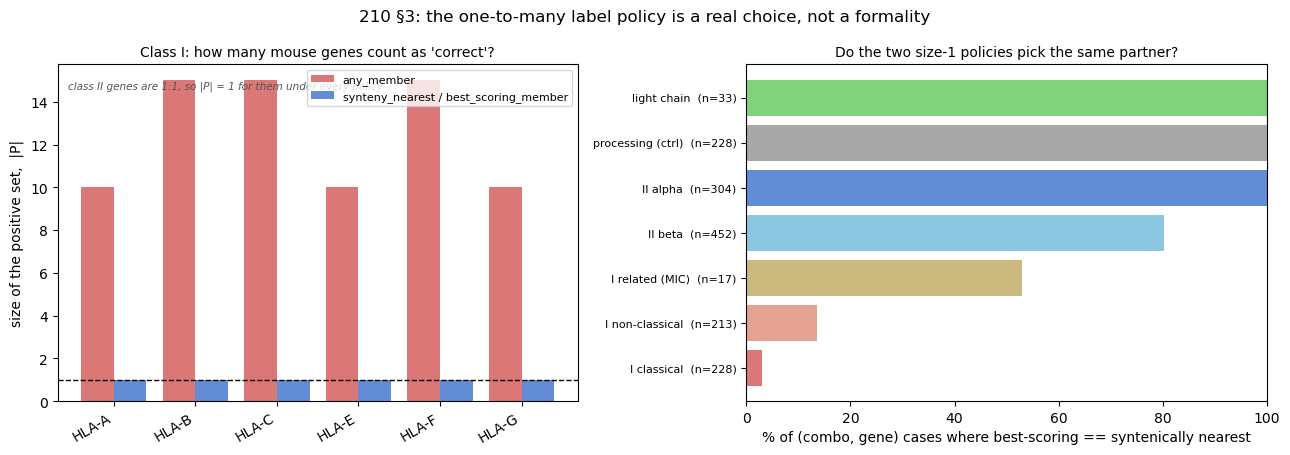

In [5]:
# Figure: how the three policies differ, gene by gene. Left panel = size of the positive set the
# policy creates for each class I gene (the whole comparability problem in one bar chart); right
# panel = whether best_scoring_member and synteny_nearest actually agree on WHICH partner, since
# if they always agreed the circularity objection would be moot.
ci_genes = [g for g in ou.MHC_CLASS_I_GENES if g in PARTNERS]
BEST = pair.filter(pl.col("label_best_scoring_member")).select(
    ["combo", "human_gene", "mouse_gene"]
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
x = np.arange(len(ci_genes))
n_any = [len(PARTNERS.get(g, ())) for g in ci_genes]
ax.bar(x - 0.2, n_any, width=0.4, color="#D65F5F", alpha=0.85, label="any_member")
ax.bar(
    x + 0.2,
    [1] * len(ci_genes),
    width=0.4,
    color="#4878CF",
    alpha=0.85,
    label="synteny_nearest / best_scoring_member",
)
ax.axhline(1, color="k", ls="--", lw=1)
ax.set_xticks(x)
ax.set_xticklabels(ci_genes, rotation=30, ha="right")
ax.set_ylabel("size of the positive set,  |P|")
ax.set_title("Class I: how many mouse genes count as 'correct'?", fontsize=10)
ax.legend(fontsize=8)
ax.text(
    0.02,
    0.95,
    "class II genes are 1:1, so |P| = 1 for them under every policy",
    transform=ax.transAxes,
    fontsize=7.5,
    style="italic",
    va="top",
    color="#555",
)

ax = axes[1]
agree = BEST.with_columns(
    pl.col("human_gene").replace_strict(SYNTENY_PARTNER, default=None).alias("syn")
).with_columns((pl.col("mouse_gene") == pl.col("syn")).alias("agrees"))
by_class = (
    agree.with_columns(
        pl.col("human_gene").replace_strict(MHC_CLASSES, default="other").alias("cls")
    )
    .group_by("cls")
    .agg((pl.col("agrees").mean() * 100).alias("pct"), pl.len().alias("n"))
    .sort("pct")
)
ax.barh(
    np.arange(by_class.height),
    by_class["pct"],
    color=[ou.MHC_CLASS_COLORS.get(c, "#999") for c in by_class["cls"]],
    alpha=0.85,
)
ax.set_yticks(np.arange(by_class.height))
ax.set_yticklabels(
    [f"{c}  (n={n})" for c, n in zip(by_class["cls"], by_class["n"])], fontsize=8
)
ax.set_xlabel("% of (combo, gene) cases where best-scoring == syntenically nearest")
ax.set_xlim(0, 100)
ax.set_title("Do the two size-1 policies pick the same partner?", fontsize=10)

fig.suptitle(
    "210 §3: the one-to-many label policy is a real choice, not a formality",
    fontsize=12,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "210_label_policy_comparison.png", dpi=150, bbox_inches="tight")

print(by_class)
print(
    "\nWhere these two disagree, `best_scoring_member` is picking the partner that scores best"
)
print(
    "under the metric being evaluated -- which is why it is a bound, not a measurement."
)

## 4. Prevalence per stratum — the number AUPRC is unreadable without

AUPRC's no-skill baseline **is** the prevalence. A stratum whose positive class is 15× larger than
another's starts from a 15× higher floor, so an AUPRC of 0.40 can be excellent in one stratum and
below chance in another. Every AUPRC in this block is reported with its prevalence next to it, via
`ou.prevalence_table`.

Prevalence is itself policy-dependent: moving from `any_member` to `synteny_nearest` shrinks class
I's positive set ~14-fold and drops its AUPRC baseline by the same factor. That is the effect that
made the old cross-class comparison unreadable.

shape: (7, 6)
┌────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬───────────────┐
│ mhc_class      ┆ n_candidates ┆ n_pos_any_memb ┆ n_pos_synteny_ ┆ median_prev_an ┆ median_prev_s │
│ ---            ┆ ---          ┆ er             ┆ nearest        ┆ y              ┆ yn            │
│ str            ┆ u32          ┆ ---            ┆ ---            ┆ ---            ┆ ---           │
│                ┆              ┆ u32            ┆ u32            ┆ f64            ┆ f64           │
╞════════════════╪══════════════╪════════════════╪════════════════╪════════════════╪═══════════════╡
│ I classical    ┆ 187081       ┆ 2198           ┆ 143            ┆ 0.059373       ┆ 0.001294      │
│ II beta        ┆ 281084       ┆ 675            ┆ 450            ┆ 0.048041       ┆ 0.032028      │
│ I              ┆ 181388       ┆ 1540           ┆ 155            ┆ 0.033349       ┆ 0.00223       │
│ non-classical  ┆              ┆                ┆                ┆          

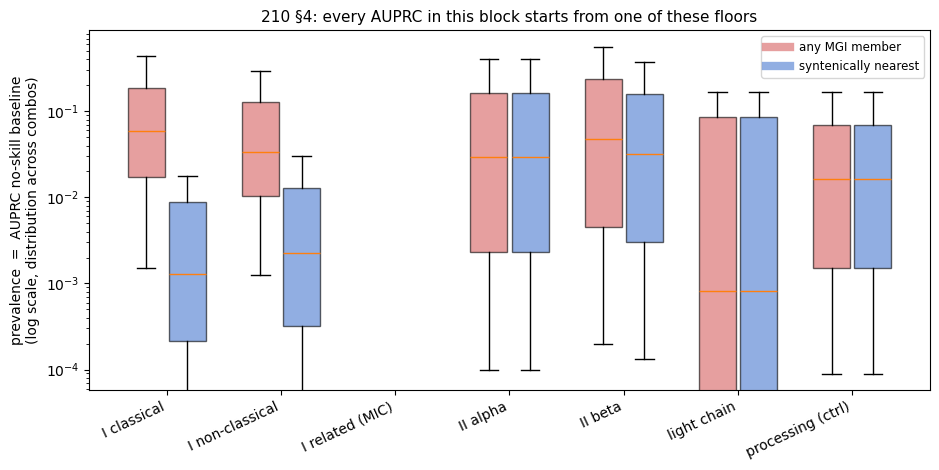

In [6]:
prev = ou.prevalence_table(pair, group_cols=("combo", "mhc_class"))
prev_by_class = (
    prev.group_by("mhc_class")
    .agg(
        [
            pl.col("n_candidates").sum(),
            pl.col("n_pos_any_member").sum(),
            pl.col("n_pos_synteny_nearest").sum(),
            pl.col("prevalence_any_member").median().alias("median_prev_any"),
            pl.col("prevalence_synteny_nearest").median().alias("median_prev_syn"),
        ]
    )
    .sort("median_prev_any", descending=True)
)
print(prev_by_class)

classes_present = [
    c
    for c in CLASS_ORDER
    if c in prev_by_class["mhc_class"].to_list()
    and prev_by_class.filter(pl.col("mhc_class") == c)["n_pos_any_member"][0] > 0
]

# The spread is computed over strata with a NON-ZERO median prevalence. "I related (MIC)" has a
# handful of positives in a handful of combos but a median of exactly 0 across combos -- mouse has
# no MICA/MICB ortholog at all, so its MGI "partners" (Mill1/Mill2, a different class-I-like
# family on chr7) are essentially never hit. A stratum whose AUPRC baseline is 0 doesn't have a
# readable AUPRC at all, which is a stronger statement than "its baseline is low"; it's reported
# separately rather than folded into a ratio that would divide by zero.
nonzero = prev_by_class.filter(pl.col("median_prev_any") > 0)
zero_strata = prev_by_class.filter(pl.col("median_prev_any") == 0)[
    "mhc_class"
].to_list()
ratio = nonzero["median_prev_any"].max() / nonzero["median_prev_any"].min()
print(
    f"\nSpread in AUPRC baseline across strata with a readable baseline (any_member): "
    f"{ratio:.0f}x -- AUPRC values are NOT comparable across these rows without it."
)
if zero_strata:
    print(
        f"Strata with a MEDIAN baseline of exactly 0 (no readable AUPRC): {zero_strata}"
    )

# The same spread under the headline policy, which is the one that matters downstream.
nz_syn = prev_by_class.filter(pl.col("median_prev_syn") > 0)
print(
    f"Same spread under synteny_nearest: "
    f"{nz_syn['median_prev_syn'].max() / nz_syn['median_prev_syn'].min():.0f}x"
)
ci_row = prev_by_class.filter(pl.col("mhc_class") == "I classical")
print(
    f"\nClass I classical baseline moves {ci_row['median_prev_any'][0] / ci_row['median_prev_syn'][0]:.0f}x "
    f"({ci_row['median_prev_any'][0]:.4f} -> {ci_row['median_prev_syn'][0]:.4f}) just by naming the policy."
)

# Figure: prevalence (= AUPRC baseline) per stratum, both policies, distribution across combos.
fig, ax = plt.subplots(figsize=(9.5, 4.8))
w = 0.36
for off, (pol, col, color) in enumerate(
    [
        ("any_member", "prevalence_any_member", "#D65F5F"),
        ("synteny_nearest", "prevalence_synteny_nearest", "#4878CF"),
    ]
):
    data = [
        prev.filter(pl.col("mhc_class") == c)[col].drop_nulls().to_numpy()
        for c in classes_present
    ]
    pos = np.arange(len(classes_present)) + (off - 0.5) * w
    bp = ax.boxplot(
        data, positions=pos, widths=w * 0.9, showfliers=False, patch_artist=True
    )
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.plot([], [], color=color, lw=6, alpha=0.6, label=ou.LABEL_POLICY_LABELS[pol])
ax.set_xticks(np.arange(len(classes_present)))
ax.set_xticklabels(classes_present, rotation=25, ha="right")
ax.set_yscale("log")
ax.set_ylabel(
    "prevalence  =  AUPRC no-skill baseline\n(log scale, distribution across combos)"
)
ax.set_title(
    "210 §4: every AUPRC in this block starts from one of these floors", fontsize=11
)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "210_prevalence_by_stratum.png", dpi=150, bbox_inches="tight")

## 5. Effective *n*: class I is not six independent observations

Every class I AUC in this project rests on **six genes**: HLA-A, -B, -C, -E, -F, -G. Six is already
small, and they are not six independent draws. The classical trio (A/B/C) are the tips of a recent,
primate-specific expansion of one ancestral locus, so they are phylogenetically correlated in the
way that makes a naive *n* overstate the evidence.

This is the same argument as "k within alphabet", one level down. Notebook 211's verdict notes that
a combo at k=24 and the same alphabet at k=25 are not two independent observations, so 73 combos is
really ~7 alphabets. Here the units are genes rather than k-sizes: **treat class I as ~2–3 effective
observations, not 6**, and read any class I number as a point estimate with no usable confidence
interval attached.

The consequence appears throughout 211: differences between alphabets on class I of less than a few
tenths of AUC should not be ranked. The jaggedness in the HP curves there is consistent with
small-*n* noise, not a real non-monotonic relationship.

class I heavy chains: n_genes = 6, n_independent_lineages = 4
  HLA-E                          ['HLA-E']
  HLA-F                          ['HLA-F']
  HLA-G                          ['HLA-G']
  classical (A/B/C expansion)    ['HLA-A', 'HLA-B', 'HLA-C']

for contrast, class II: n_genes = 13, and they are 1:1 with mouse (median MGI partners = 1) -- which is why class II is the statistically solid half of this benchmark and class I is not.


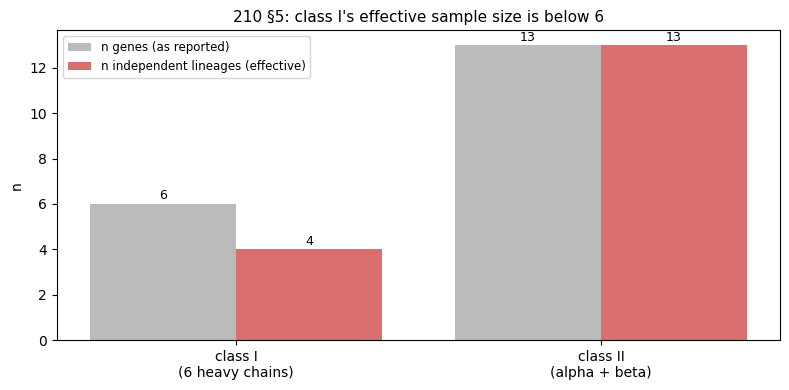

In [7]:
# Effective n, made explicit rather than left as a caveat sentence. Class I heavy chains fall into
# lineage groups: the classical trio A/B/C descend from one recent primate-specific expansion, and
# the non-classical genes E/F/G are older, more separated lineages (Shiina et al. 2017, Immunology
# 150:127-138, doi:10.1111/imm.12624). Counting lineages rather than genes is the honest n.
CLASS_I_LINEAGES = {
    "HLA-A": "classical (A/B/C expansion)",
    "HLA-B": "classical (A/B/C expansion)",
    "HLA-C": "classical (A/B/C expansion)",
    "HLA-E": "HLA-E",
    "HLA-F": "HLA-F",
    "HLA-G": "HLA-G",
}
n_genes = len(ci_genes)
n_lineages = len({CLASS_I_LINEAGES[g] for g in ci_genes})
print(
    f"class I heavy chains: n_genes = {n_genes}, n_independent_lineages = {n_lineages}"
)
for lin in sorted(set(CLASS_I_LINEAGES.values())):
    members = [g for g in ci_genes if CLASS_I_LINEAGES[g] == lin]
    print(f"  {lin:30s} {members}")

class_ii = [g for g, c in MHC_CLASSES.items() if c.startswith("II")]
print(
    f"\nfor contrast, class II: n_genes = {len(class_ii)}, and they are 1:1 with mouse "
    f"(median MGI partners = "
    f"{int(np.median([len(PARTNERS.get(g, ())) for g in class_ii]))}) -- "
    f"which is why class II is the statistically solid half of this benchmark and class I is not."
)

# Figure: n as reported vs n effective, alongside |P| under each policy -- the two independent
# reasons a class I number is weaker than it looks, on one axis.
fig, ax = plt.subplots(figsize=(8, 4))
groups = ["class I\n(6 heavy chains)", "class II\n(alpha + beta)"]
naive = [n_genes, len(class_ii)]
effective = [n_lineages, len(class_ii)]
x = np.arange(len(groups))
ax.bar(x - 0.2, naive, width=0.4, color="#bbbbbb", label="n genes (as reported)")
ax.bar(
    x + 0.2,
    effective,
    width=0.4,
    color="#D65F5F",
    alpha=0.9,
    label="n independent lineages (effective)",
)
for xi, (a, b) in enumerate(zip(naive, effective)):
    ax.text(xi - 0.2, a + 0.2, str(a), ha="center", fontsize=9)
    ax.text(xi + 0.2, b + 0.2, str(b), ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel("n")
ax.set_title("210 §5: class I's effective sample size is below 6", fontsize=11)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig(FIG_DIR / "210_effective_n.png", dpi=150, bbox_inches="tight")

## 6. What the rest of the block reads

Two artifacts, both written below, plus the constants that now live in `ortholog_analysis_utils`
(`ou.MHC_CLASSES`, `ou.DOMAINS_CLASS_I`, `ou.ARD_I`/`IG_I`/`TM_I`, `ou.CONTACT_PROT`,
`ou.MOUSE_DOMAINS_I`, `ou.mhc_gene_arch`):

| artifact | columns | read by |
|---|---|---|
| `210_mhc_pair_table.parquet` | one row per (combo, human, mouse) + all three label columns | 211, 213, 214, 215 |
| `210_mhc_matched_regions.parquet` | every matched region with query/target coordinates | 212, 214 |

Notebooks 211–215 **must not** recompute labels. If a label rule needs to change, it changes here.

In [8]:
pair = pair.with_columns(
    pl.col("combo").is_in(list(NO_DATA_LABELS)).alias("pipeline_gap")
)
pair.write_parquet(RES / "210_mhc_pair_table.parquet")
print(
    f"Wrote {RES / '210_mhc_pair_table.parquet'}: {pair.height:,} rows x {pair.width} cols"
)
print(f"  label columns: {[c for c in pair.columns if c.startswith('label_')]}")
print(f"  combos with data: {pair['combo'].n_unique()}/{len(COMBOS)}")

# Round-trip guard: a downstream notebook reading this file must get boolean labels, not strings,
# and must find every policy column present. Cheap to check here, expensive to debug in 213.
_rt = pl.read_parquet(RES / "210_mhc_pair_table.parquet")
for col in ou.LABEL_POLICY_COLS.values():
    assert col in _rt.columns, f"missing {col}"
    assert _rt[col].dtype == pl.Boolean, f"{col} is {_rt[col].dtype}, expected Boolean"
print("\nRound-trip check passed: all three label policies present and boolean.")

Wrote /Users/olga/data/gencode/results-human-mouse-orthologs/210_mhc_pair_table.parquet: 1,256,268 rows x 14 cols
  label columns: ['label_any_member', 'label_synteny_nearest', 'label_best_scoring_member']
  combos with data: 76/77

Round-trip check passed: all three label policies present and boolean.


## Verdict

**Naming the label policy moves class I's AUPRC baseline by 45×.** Class I classical's prevalence,
which *is* the AUPRC no-skill floor, is 0.0628 under `any_member` and 0.0014 under
`synteny_nearest`. Every class I number published before this notebook existed was computed under
`any_member` without saying so, so it answered "can kmerseek find *a* mouse class I gene?" while
being read as "can kmerseek find *the* ortholog?" Those are different questions, and the second is
the one the benchmark claims to answer.

**The two size-1 policies agree where the genes are 1:1 and disagree where they are not.**
`best_scoring_member` and `synteny_nearest` pick the same mouse partner in **100%** of cases for
class II alpha, the light chain, and the processing controls (all 1:1 genes), **79%** for class II
beta, but **13%** for class I non-classical and **3%** for class I classical. Where a gene has one
real ortholog, "highest-scoring" and "syntenically nearest" are the same gene and the policy is
irrelevant. Where a gene has fifteen candidates, they are almost never the same gene, and the choice
determines the answer.

**The synteny assignment is well-supported for the genes that matter:** 20 of 23 assignments
interpolate between real flanking anchors on mouse chr17, with a median partner-to-prediction
distance in the tens of kb. The three exceptions are MICA and MICB (chr7 → Mill1/Mill2, no anchors
there, since mouse has no MHC-region ortholog for these) and one chr2 case. HLA-A's 927 kb distance
is the largest, and reflects the fan-out spread of the class I cluster rather than a failure of the
map.

**Three consequences for 211–215.**

1. **Report the policy with every class I number.** `synteny_nearest` is the headline, as the only
   size-1 rule decided by evidence independent of the sequence being scored. `best_scoring_member`
   is reported as an upper bound and flagged as circular. `any_member` is kept for continuity with
   the older numbers, not because it is comparable.
2. **Never compare an AUPRC across strata without its prevalence.** §4's spread is large enough that
   the ranking of two strata can invert depending on whether the baseline is subtracted.
3. **Do not rank alphabets on class I by small AUC differences.** §5's effective *n* is 2–3, not 6.
   Class II is the statistically solid half of this benchmark; class I is a stress test whose
   direction is informative and whose exact ordering is not.

**What this does not fix.** MGI's partner list is still the candidate pool for all three policies,
and MGI is partly sequence-derived, so all three inherit that circularity. `synteny_nearest` removes
it from the *choice among* partners, not from the *set of* partners. Notebook 215 tests that
assumption against genomic position directly, without MGI in the loop at all.